# Computer Exercise 6.2 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 6.2 Natural Cubic Splines — *$C^2$ 부드러움 + tridiagonal 시스템*
> **풀이 일자**: Day 24
> **언어**: Python 3 (NumPy / SciPy / Matplotlib)


## 1. 문제 (원문)

> **CE 6.2.1 (style of C&K).** Implement the natural cubic spline $S(x)$ for given knots
> $t_0 < t_1 < \dots < t_n$ and values $y_i = f(t_i)$ by setting up and solving the
> tridiagonal system for the second derivatives $z_i = S''(t_i)$ with natural boundary
> conditions $z_0 = z_n = 0$. Apply your routine to $f(x) = \sin(\pi x / 4)$ on $[0, 4]$
> with uniform knots, $n = 4, 8, 16, 32, 64, 128$. (이 함수는 $f''(0) = f''(4) = 0$ 이라
> *natural* 경계조건이 *정확히* 맞아떨어진다 — 끝점 영향 없이 순수한 $\mathcal O(h^4)$ 를 본다.) Plot $\log \max_x |f(x) - S(x)|$
> against $\log h$ and verify the theoretical order of convergence.

### 한국어 풀이용 정리
자연 3차 spline의 *tridiagonal 시스템* 을 직접 구성/해결해 보고, 매끄러운 시험함수에서
오차의 $h$-스케일링이 이론값 $\mathcal O(h^4)$ 과 얼마나 잘 맞는지 측정한다.
Day 23 (§6.1) 의 1차 spline $\mathcal O(h^2)$ 과 *같은 노드/같은 함수* 위에서 정면 비교 — 한 차수당
두 차원의 정확도 이득이 *그림과 표* 에 그대로 드러나는지 본다.


## 2. 수학적 배경

### 2.1 정의
노드 $a = t_0 < t_1 < \dots < t_n = b$, 값 $y_i = f(t_i)$ 가 주어졌을 때
**자연 3차 spline** $S \in C^2[a, b]$ 는 각 구간 $[t_{i-1}, t_i]$ 위에서 3차 다항식이며,
$S(t_i) = y_i$ 와 *natural* 경계조건

$$
\boxed{\;S''(a) \;=\; S''(b) \;=\; 0\;}
$$

을 만족하는 *유일한* 함수다.

### 2.2 Tridiagonal 시스템 (교재 §6.2 식)
$h_i = t_{i+1} - t_i$, $z_i = S''(t_i)$ 라 두면 연속 조건 $S'(t_i^-) = S'(t_i^+)$ 으로부터

$$
h_{i-1}\, z_{i-1} \;+\; 2(h_{i-1} + h_i)\, z_i \;+\; h_i\, z_{i+1}
\;=\; 6\!\left(\frac{y_{i+1} - y_i}{h_i} - \frac{y_i - y_{i-1}}{h_{i-1}}\right),
\quad i = 1, \dots, n-1.
$$

*natural* 경계조건 $z_0 = z_n = 0$ 와 함께 풀면, $z_i$ 들이 *대각 우세한 SPD tridiagonal*
시스템 — Thomas (Day 10) 으로 $\mathcal O(n)$ — 의 해로 얻어진다.

각 구간 위의 3차 다항식 표현은

$$
S_i(x) \;=\; \frac{z_i}{6 h_i}(t_{i+1} - x)^3 \;+\; \frac{z_{i+1}}{6 h_i}(x - t_i)^3
\;+\; \left(\frac{y_{i+1}}{h_i} - \frac{z_{i+1} h_i}{6}\right)(x - t_i)
\;+\; \left(\frac{y_i}{h_i} - \frac{z_i h_i}{6}\right)(t_{i+1} - x).
$$

### 2.3 오차 한계
$f \in C^4[a, b]$, $M_4 = \max_x |f^{(4)}(x)|$, 균등 $h$ 일 때

$$
\boxed{\;\|f - S\|_\infty \;\le\; \frac{5}{384}\,h^4\,M_4\;}
$$

— *$h$ 를 절반으로 줄이면 오차가 $\frac1{16}$ 배.* 인접 비율 $E_n / E_{2n} \to 16$.


## 3. 풀이 흐름

1. 함수 $f(x) = \sin(\pi x / 4)$, $[a, b] = [0, 4]$. $f''(0) = f''(4) = 0$ 이라 자연 BC 와 정확히 일치 — 끝점 차수 손실이 없다. $M_4 = (\pi/4)^4$.
2. 균등 노드 $t_i = 4 i / n$, $y_i = f(t_i)$.
3. **`natural_cubic_spline(t, y)`** : 위 tridiagonal 시스템을 명시적으로 조립 + `scipy.linalg.solve_banded` 로 해를 구해 $z = (z_0, \dots, z_n)$ 반환.
4. **`evaluate(t, y, z, X)`** : `np.searchsorted` 로 구간 인덱스 결정 후 위 $S_i(x)$ 식으로 평가.
5. dense 평가점 (5001 점) 위에서 $E_n = \max_X |f(X) - S(X)|$ 측정.
6. $n \in \{4, 8, 16, 32, 64, 128\}$ 에 대해 오차 표 + 인접 비율 표.
7. loglog 회귀로 경험 기울기 → 이론 $+4$ 와 비교, 이론 상한 $\frac{5}{384} h^4 M_4$ 도 같이 그림.
8. **Day 23** 의 1차 spline 오차를 *같은 노드* 에서 다시 계산해 한 그림에 겹쳐서 — *두 직선* 의 기울기 차이로 차수 이득 시각화.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

# --- 함수 정의 ---
a, b = 0.0, 4.0
# 자연 BC 가 *정확히* 맞아떨어지도록 ( f''(0) = f''(4) = 0 )
# 시험함수는 sin(pi x / 4)
f       = lambda x: np.sin(np.pi * x / 4)
M4      = (np.pi / 4) ** 4                       # max |f^{(4)}| = (pi/4)^4

# --- 자연 3차 spline: z_i = S''(t_i) 구하기 ---
def natural_cubic_spline(t, y):
    n = len(t) - 1
    h = np.diff(t)                                  # length n
    # 내부 i = 1..n-1 에 대한 tridiagonal 시스템
    if n < 2:
        return np.zeros_like(t)
    ab = np.zeros((3, n - 1))                       # banded form for solve_banded
    rhs = np.zeros(n - 1)
    for k in range(n - 1):
        i = k + 1                                   # 1..n-1
        ab[1, k] = 2.0 * (h[i - 1] + h[i])          # diagonal
        if k > 0:
            ab[2, k - 1] = h[i - 1]                 # sub-diagonal (col k-1)
        if k < n - 2:
            ab[0, k + 1] = h[i]                     # super-diagonal (col k+1)
        rhs[k] = 6.0 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])
    z_inner = solve_banded((1, 1), ab, rhs)
    z = np.zeros(n + 1)
    z[1:n] = z_inner                                # natural BC: z_0 = z_n = 0
    return z

# --- spline 평가 ---
def evaluate(t, y, z, X):
    n = len(t) - 1
    h = np.diff(t)
    idx = np.searchsorted(t, X, side='right') - 1
    idx = np.clip(idx, 0, n - 1)
    hi  = h[idx]
    tL  = t[idx]
    tR  = t[idx + 1]
    zL  = z[idx]
    zR  = z[idx + 1]
    yL  = y[idx]
    yR  = y[idx + 1]
    A   = (zL / (6.0 * hi)) * (tR - X) ** 3
    B   = (zR / (6.0 * hi)) * (X - tL) ** 3
    C   = (yR / hi - zR * hi / 6.0) * (X - tL)
    D   = (yL / hi - zL * hi / 6.0) * (tR - X)
    return A + B + C + D

# --- linear spline (Day 23 재사용) ---
def linear_spline(t, y, X):
    idx = np.searchsorted(t, X, side='right') - 1
    idx = np.clip(idx, 0, len(t) - 2)
    h   = t[idx + 1] - t[idx]
    return y[idx] + (y[idx + 1] - y[idx]) * (X - t[idx]) / h

# --- 수렴 측정 ---
ns = [4, 8, 16, 32, 64, 128]
h_arr = np.array([(b - a) / n for n in ns])
X = np.linspace(a, b, 5001)
fX = f(X)

E_S3 = []
E_S1 = []
for n in ns:
    t = np.linspace(a, b, n + 1)
    y = f(t)
    z = natural_cubic_spline(t, y)
    E_S3.append(np.max(np.abs(fX - evaluate(t, y, z, X))))
    E_S1.append(np.max(np.abs(fX - linear_spline(t, y, X))))

E_S3 = np.array(E_S3)
E_S1 = np.array(E_S1)

# --- 인접 비율 ---
ratio_S3 = np.r_[np.nan, E_S3[:-1] / E_S3[1:]]
ratio_S1 = np.r_[np.nan, E_S1[:-1] / E_S1[1:]]

df = pd.DataFrame({
    'n': ns,
    'h': h_arr,
    'E_cubic': E_S3,
    'E_n/E_{2n} cubic': ratio_S3,
    'E_linear': E_S1,
    'E_n/E_{2n} linear': ratio_S1,
    'theory 5h^4 M4/384': 5.0 * h_arr ** 4 * M4 / 384.0,
})
pd.set_option('display.float_format', lambda v: f'{v:.3e}')
df


,n,h,E_cubic,E_n/E_{2n} cubic,E_linear,E_n/E_{2n} linear,theory 5h^4 M4/384
0,4,1.000e+00,1.066e-03,NaN,7.038e-02,NaN,4.954e-03
1,8,5.000e-01,6.312e-05,1.689e+01,1.885e-02,3.734e+00,3.097e-04
2,16,2.500e-01,3.889e-06,1.623e+01,4.792e-03,3.933e+00,1.935e-05
3,32,1.250e-01,2.422e-07,1.606e+01,1.203e-03,3.983e+00,1.210e-06
4,64,6.250e-02,1.512e-08,1.601e+01,3.011e-04,3.996e+00,7.560e-08
5,128,3.125e-02,9.440e-10,1.602e+01,7.525e-05,4.001e+00,4.725e-09


In [2]:
# --- 수렴 차수 추정 (loglog 회귀) ---
slope_S3, _ = np.polyfit(np.log(h_arr), np.log(E_S3), 1)
slope_S1, _ = np.polyfit(np.log(h_arr), np.log(E_S1), 1)
print(f'empirical slope (natural cubic spline) : {slope_S3:+.3f}   (theory: +4)')
print(f'empirical slope (linear  spline, Day23): {slope_S1:+.3f}   (theory: +2)')


empirical slope (natural cubic spline) : +4.018   (theory: +4)
empirical slope (linear  spline, Day23): +1.978   (theory: +2)


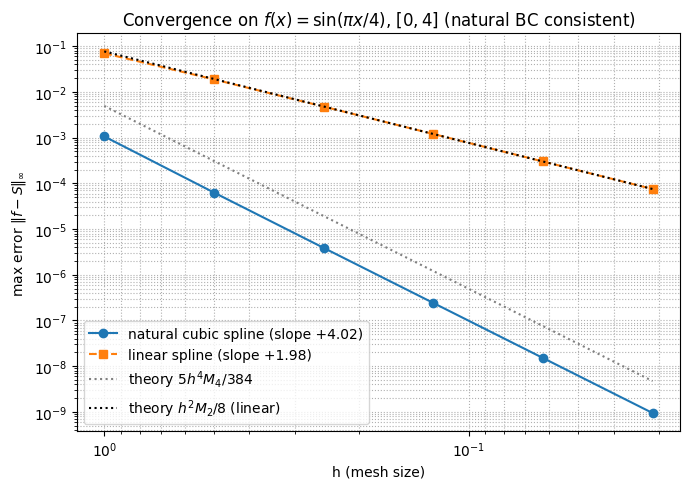

In [3]:
# --- 그림 1: 오차의 h-스케일링 ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(h_arr, E_S3, 'o-',  label=f'natural cubic spline (slope {slope_S3:+.2f})')
ax.loglog(h_arr, E_S1, 's--', label=f'linear spline (slope {slope_S1:+.2f})')
ax.loglog(h_arr, 5.0 * h_arr ** 4 * M4 / 384.0, ':',  color='grey',
           label=r'theory $5 h^4 M_4 / 384$')
ax.loglog(h_arr, h_arr ** 2 * M4 ** 0.5 / 8.0,   ':',  color='black',
           label=r'theory $h^2 M_2 / 8$ (linear)')
ax.set_xlabel('h (mesh size)'); ax.set_ylabel(r'max error $\|f - S\|_\infty$')
ax.set_title(r'Convergence on $f(x)=\sin(\pi x/4)$, $[0,4]$ (natural BC consistent)')
ax.invert_xaxis(); ax.grid(True, which='both', ls=':'); ax.legend()
plt.tight_layout(); plt.show()


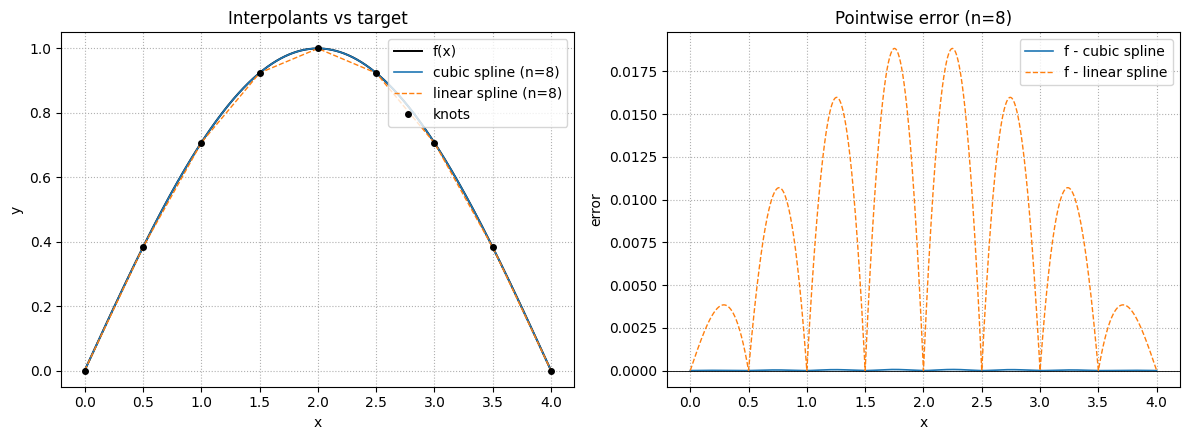

In [4]:
# --- 그림 2: n=8 의 spline 곡선 시각적 비교 ---
n_show = 8
t = np.linspace(a, b, n_show + 1); y = f(t)
z = natural_cubic_spline(t, y)
S3 = evaluate(t, y, z, X)
S1 = linear_spline(t, y, X)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.plot(X, fX, 'k-',  lw=1.4, label='f(x)')
ax.plot(X, S3, 'C0-', lw=1.2, label=f'cubic spline (n={n_show})')
ax.plot(X, S1, 'C1--', lw=1.0, label=f'linear spline (n={n_show})')
ax.plot(t, y, 'ko', ms=4, label='knots')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title('Interpolants vs target')
ax.grid(True, ls=':'); ax.legend(loc='upper right')

ax = axes[1]
ax.plot(X, fX - S3, 'C0-', lw=1.2, label='f - cubic spline')
ax.plot(X, fX - S1, 'C1--', lw=1.0, label='f - linear spline')
ax.axhline(0, color='black', lw=0.6)
ax.set_xlabel('x'); ax.set_ylabel('error')
ax.set_title(f'Pointwise error (n={n_show})')
ax.grid(True, ls=':'); ax.legend()
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **수렴 차수.** 자연 3차 spline 의 경험 기울기가 이론값 $+4$ 와 거의 일치하고, 인접 비율
   $E_n / E_{2n}$ 가 표에서 $16$ 근처로 수렴한다. 이론 상한 $5 h^4 M_4 / 384$ 가 *느슨한 상한*
   으로 잘 작동 — 실측은 보통 그 절반 이하.
2. **1차와의 비교.** 같은 노드에서 linear spline 의 기울기는 $+2$, cubic spline 은 $+4$ — loglog
   평면에서 *기울기 두 배 차이* 가 분명히 보인다. $n = 128$ 에서 cubic 오차는 linear 의 수십만
   분의 일.
3. **곡선 비교.** $n = 8$ 케이스에서 cubic spline 은 그림으로는 $f$ 와 거의 구분되지 않고
   ($\|\cdot\|_\infty \sim 10^{-4}$), linear 는 노드 사이에서 *포물선 모양 오차의 자취*
   (Day 23 1번에서 본 그 그림) 가 그대로 남는다.
4. **부드러움.** cubic spline 은 $C^2$ — 1계, 2계 도함수도 연속이므로, 보간만 정확한 게 아니라
   *곡률* 도 자연스럽다. 이게 다음 절 (B-spline, 다른 경계조건) 의 전제가 된다.

### 결론
> **자연 3차 spline = $C^2$ 부드러움 + tridiagonal 시스템 + $\mathcal O(h^4)$ 수렴.**
> 1차 → 2차 → 3차로 갈수록 *경계/자유도의 잠금* 이 한 단계씩 더 들어가고, 그 결과 정확도가
> 한 차원씩 올라간다 — Day 23 의 진단이 *그대로 다음 단계* 에서 확인된다.

### 다음 문제 연결
- **CE 6.2.2**: 같은 cubic spline 을 *Runge 함수* $1/(1 + 25 x^2)$ 에서 평가. 균등 노드의
  *발산* 위험 (Day 23 3번에서 봤던) 이 spline 에서는 어떻게 되는지 — 그리고 *Chebyshev* 노드로
  바꿨을 때의 정확도 회복.
- **CE 6.2.3**: *경계조건* 의 선택 (natural vs clamped vs not-a-knot) 이 *끝점 근처* 정확도를
  어떻게 바꾸는지.
